# 📊 Khám phá & Phân tích Dữ liệu


## 1. Import thư viện & Cấu hình


In [14]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter
from pathlib import Path

# Cấu hình hiển thị
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['figure.dpi'] = 100

# Seed cho reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("✅ Đã import thư viện thành công!")


✅ Đã import thư viện thành công!


In [15]:
# Đường dẫn Kaggle
TRAIN_DATA_ROOT = "/kaggle/input/uit-uwdb-line/UIT_HWDB_line/train_data"
TEST_DATA_ROOT = "/kaggle/input/uit-uwdb-line/UIT_HWDB_line/test_data"

def load_folder_based_dataset(data_root):
    """Đọc dữ liệu từ cấu trúc folder-based với label.json"""
    records = []

    if not os.path.exists(data_root):
        print(f"❌ Không tìm thấy folder: {data_root}")
        return pd.DataFrame()

    print(f"🔍 Đang scan folder: {data_root}")

    # Duyệt qua các folder con (sắp xếp theo số)
    try:
        subfolders = sorted([f for f in os.listdir(data_root) if os.path.isdir(os.path.join(data_root, f))],
                          key=lambda x: int(x) if x.isdigit() else x)
    except:
        subfolders = sorted([f for f in os.listdir(data_root) if os.path.isdir(os.path.join(data_root, f))])

    for folder_name in subfolders:
        folder_path = os.path.join(data_root, folder_name)
        label_file = os.path.join(folder_path, "label.json")

        if not os.path.exists(label_file):
            continue

        # Đọc label.json
        try:
            with open(label_file, 'r', encoding='utf-8') as f:
                labels = json.load(f)

            # Tạo record cho mỗi ảnh trong folder
            for img_name, text in labels.items():
                img_path = os.path.join(folder_path, img_name)
                if os.path.exists(img_path):
                    records.append({
                        "image": img_path,
                        "text": text,
                        "folder": folder_name
                    })

        except Exception as e:
            print(f"⚠️ Lỗi đọc {label_file}: {e}")
            continue

    df = pd.DataFrame(records)
    print(f"✅ Đã load {len(df)} mẫu từ {len(subfolders)} folder")
    return df

# Đọc dữ liệu
df_train = load_folder_based_dataset(TRAIN_DATA_ROOT)
df_test = load_folder_based_dataset(TEST_DATA_ROOT)

print(f"\n📊 Tổng quan:\n   - Train: {len(df_train)} mẫu\n   - Test: {len(df_test)} mẫu")


🔍 Đang scan folder: /kaggle/input/uit-uwdb-line/UIT_HWDB_line/train_data
✅ Đã load 7028 mẫu từ 249 folder
🔍 Đang scan folder: /kaggle/input/uit-uwdb-line/UIT_HWDB_line/test_data
✅ Đã load 201 mẫu từ 6 folder

📊 Tổng quan:
   - Train: 7028 mẫu
   - Test: 201 mẫu


## 2. Đọc dữ liệu


In [16]:
# Xem cấu trúc dữ liệu
print("🔍 Cấu trúc dữ liệu Train:")
display(df_train.head(3))

print("\n📋 Thông tin cột:")
print(df_train.dtypes)


🔍 Cấu trúc dữ liệu Train:


,image,text,folder
0,/kaggle/input/uit-uwdb-line/UIT_HWDB_line/trai...,KHÁI QUÁT VỀ BIỂN ĐẢO VIỆT NAM,1
1,/kaggle/input/uit-uwdb-line/UIT_HWDB_line/trai...,Nước ta giáp với biển Đông ở hai phía Đông và ...,1
2,/kaggle/input/uit-uwdb-line/UIT_HWDB_line/trai...,Đông.,1



📋 Thông tin cột:
image     object
text      object
folder    object
dtype: object


## 3. Hiển thị mẫu dữ liệu


🖼️ Một số mẫu ngẫu nhiên từ tập Train:


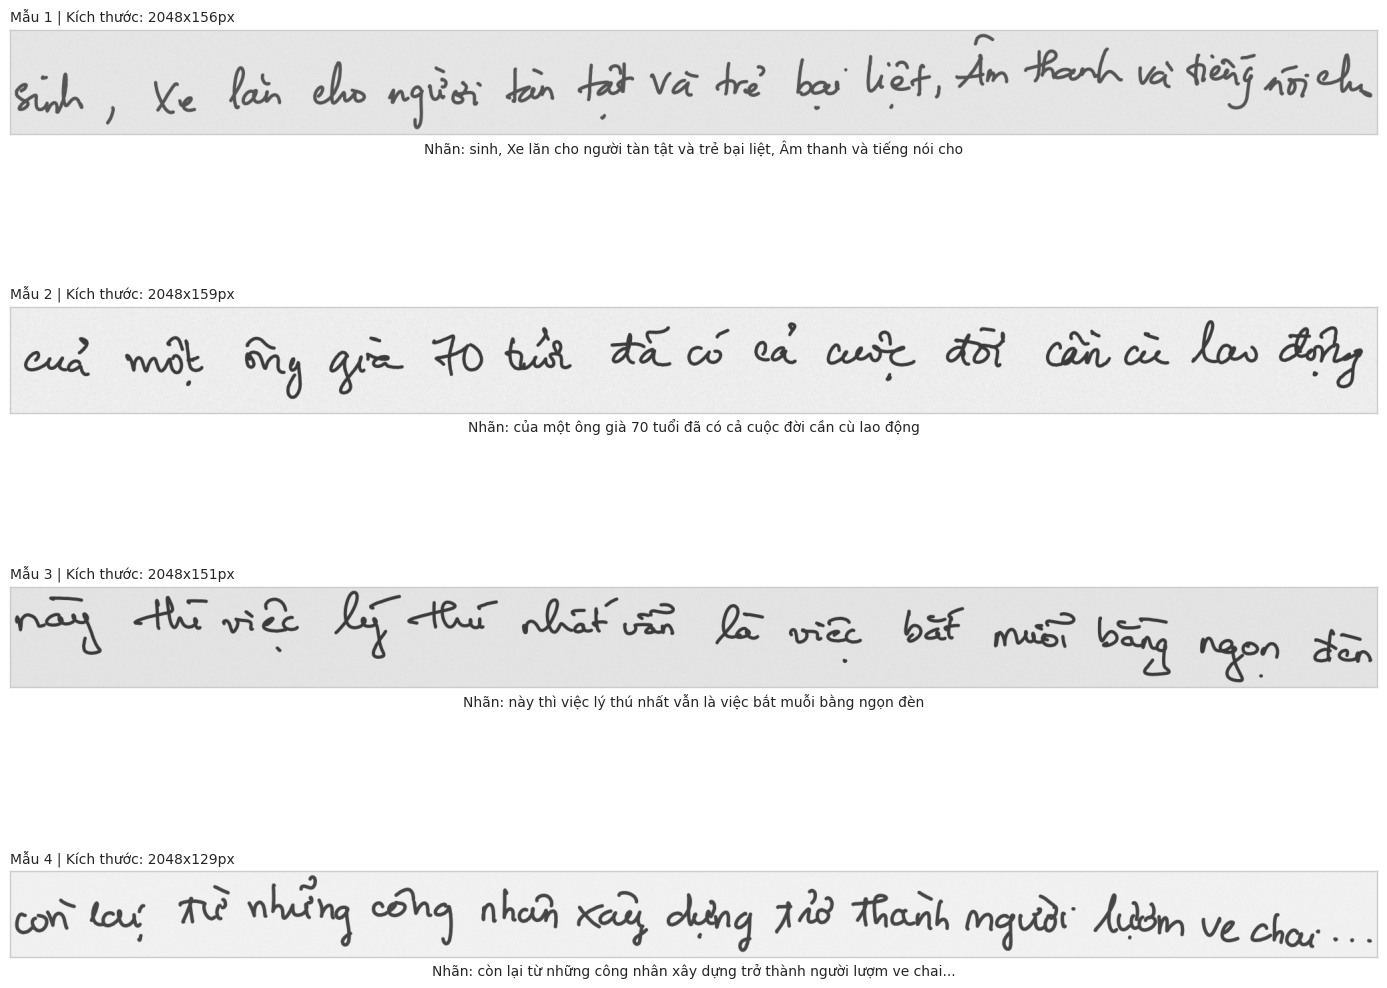

In [17]:
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['font.family'] = 'sans-serif'

def display_random_samples(dataframe, n_samples=4):
    """Hiển thị ngẫu nhiên một số mẫu ảnh và nhãn"""
    if dataframe.empty:
        print("DataFrame trống!")
        return
    
    samples = dataframe.sample(n=min(n_samples, len(dataframe)), random_state=SEED)
    
    fig, axes = plt.subplots(n_samples, 1, figsize=(14, 3*n_samples))
    if n_samples == 1:
        axes = [axes]
    
    for idx, (ax, (_, row)) in enumerate(zip(axes, samples.iterrows())):
        img_path = row['image']
        label = row['text']
        
        try:
            img = Image.open(img_path).convert('RGB')
            ax.imshow(img)
            ax.set_title(f"Mẫu {idx+1} | Kích thước: {img.size[0]}x{img.size[1]}px", fontsize=10, loc='left')
            ax.set_xlabel(f"Nhãn: {label}", fontsize=10)
            ax.set_xticks([])
            ax.set_yticks([])
        except Exception as e:
            ax.text(0.5, 0.5, f"Lỗi: {e}", ha='center', va='center')
            ax.axis('off')
    
    plt.tight_layout()
    plt.show()

print("🖼️ Một số mẫu ngẫu nhiên từ tập Train:")
display_random_samples(df_train, n_samples=4)

## 4. Phân tích văn bản (Ground Truth)


In [18]:
# Thêm cột độ dài văn bản
df_train['text_length'] = df_train['text'].apply(len)

# Thống kê
stats = df_train['text_length'].describe()
print("📈 Thống kê độ dài văn bản (số ký tự):")
print(f"   - Trung bình: {stats['mean']:.1f}")
print(f"   - Độ lệch chuẩn: {stats['std']:.1f}")
print(f"   - Min: {stats['min']:.0f} | Max: {stats['max']:.0f}")
print(f"   - Median: {stats['50%']:.0f}")


📈 Thống kê độ dài văn bản (số ký tự):
   - Trung bình: 67.8
   - Độ lệch chuẩn: 18.5
   - Min: 2 | Max: 158
   - Median: 71


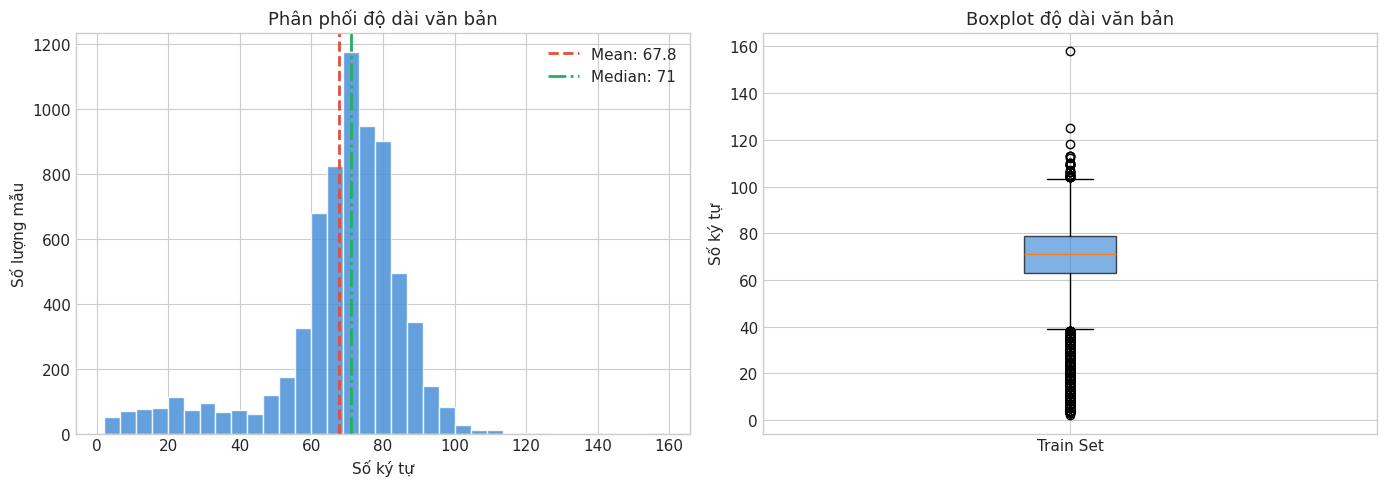

In [19]:
# Biểu đồ phân phối độ dài văn bản
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df_train['text_length'], bins=35, color='#4A90D9', edgecolor='white', alpha=0.85)
axes[0].axvline(df_train['text_length'].mean(), color='#E74C3C', linestyle='--', linewidth=2, label=f'Mean: {df_train["text_length"].mean():.1f}')
axes[0].axvline(df_train['text_length'].median(), color='#27AE60', linestyle='-.', linewidth=2, label=f'Median: {df_train["text_length"].median():.0f}')
axes[0].set_xlabel('Số ký tự')
axes[0].set_ylabel('Số lượng mẫu')
axes[0].set_title('Phân phối độ dài văn bản')
axes[0].legend()

# Boxplot
bp = axes[1].boxplot(df_train['text_length'], vert=True, patch_artist=True)
bp['boxes'][0].set_facecolor('#4A90D9')
bp['boxes'][0].set_alpha(0.7)
axes[1].set_ylabel('Số ký tự')
axes[1].set_title('Boxplot độ dài văn bản')
axes[1].set_xticklabels(['Train Set'])

plt.tight_layout()
plt.show()


In [20]:
# Phân tích ký tự
all_chars = ''.join(df_train['text'].tolist())
char_freq = Counter(all_chars)
unique_chars = sorted(set(all_chars))

print(f"📊 Phân tích bộ ký tự:")
print(f"   - Tổng số ký tự: {len(all_chars):,}")
print(f"   - Số ký tự duy nhất: {len(unique_chars)}")

# Kiểm tra ký tự tiếng Việt đặc biệt
vn_special = [c for c in unique_chars if ord(c) > 127]
print(f"   - Số ký tự tiếng Việt (có dấu): {len(vn_special)}")
print(f"   - Ví dụ: {''.join(vn_special[:30])}...")


📊 Phân tích bộ ký tự:
   - Tổng số ký tự: 476,565
   - Số ký tự duy nhất: 161
   - Số ký tự tiếng Việt (có dấu): 86
   - Ví dụ: ÀÁÂÔÚÝàáâãèéêìíòóôõùúýĂăĐđĩũƠơ...


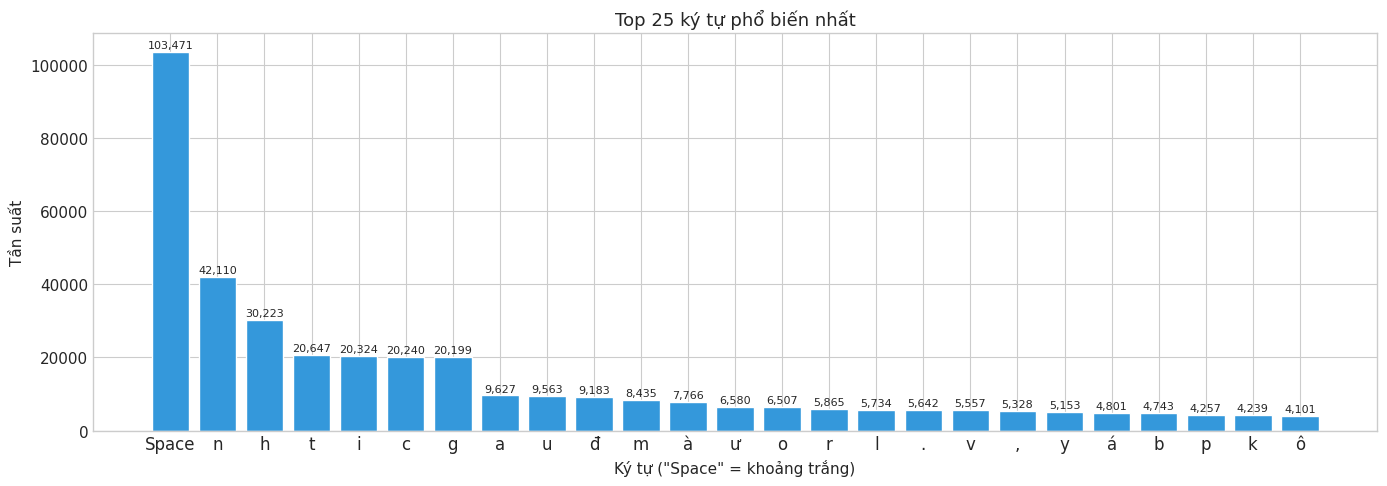

In [21]:
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['font.family'] = 'sans-serif'

# Top ký tự phổ biến nhất
top_chars = char_freq.most_common(25)

chars = [c if c != ' ' else 'Space' for c, _ in top_chars] 
counts = [cnt for _, cnt in top_chars]

plt.figure(figsize=(14, 5))
bars = plt.bar(chars, counts, color='#3498DB', edgecolor='white')

plt.xlabel('Ký tự ("Space" = khoảng trắng)') 
plt.ylabel('Tần suất')
plt.title('Top 25 ký tự phổ biến nhất')
plt.xticks(fontsize=12)

# Thêm giá trị trên cột
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, 
             f'{count:,}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

## 5. Phân tích hình ảnh


In [22]:
def extract_image_info(img_path):
    """Trích xuất thông tin kích thước ảnh"""
    try:
        with Image.open(img_path) as img:
            return {'width': img.size[0], 'height': img.size[1], 'valid': True}
    except:
        return {'width': 0, 'height': 0, 'valid': False}

# Lấy mẫu để phân tích (tránh quá lâu nếu dataset lớn)
sample_size = min(1000, len(df_train))
sample_df = df_train.sample(n=sample_size, random_state=SEED).copy()

print(f"🔍 Đang phân tích {sample_size} ảnh...")
img_info = sample_df['image'].apply(extract_image_info)
sample_df['width'] = img_info.apply(lambda x: x['width'])
sample_df['height'] = img_info.apply(lambda x: x['height'])
sample_df['valid'] = img_info.apply(lambda x: x['valid'])

# Lọc ảnh hợp lệ
valid_df = sample_df[sample_df['valid'] == True]
print(f"✅ Số ảnh hợp lệ: {len(valid_df)}/{sample_size}")


🔍 Đang phân tích 1000 ảnh...
✅ Số ảnh hợp lệ: 1000/1000


In [23]:
# Thống kê kích thước ảnh
print("📐 Thống kê kích thước ảnh:")
print(f"   Chiều rộng (Width):")
print(f"      - Trung bình: {valid_df['width'].mean():.1f} px")
print(f"      - Min/Max: {valid_df['width'].min()} / {valid_df['width'].max()} px")
print(f"   Chiều cao (Height):")
print(f"      - Trung bình: {valid_df['height'].mean():.1f} px")
print(f"      - Min/Max: {valid_df['height'].min()} / {valid_df['height'].max()} px")

# Tỷ lệ khung hình
valid_df['aspect_ratio'] = valid_df['width'] / valid_df['height']
print(f"   Tỷ lệ khung hình (W/H):")
print(f"      - Trung bình: {valid_df['aspect_ratio'].mean():.2f}")


📐 Thống kê kích thước ảnh:
   Chiều rộng (Width):
      - Trung bình: 2048.0 px
      - Min/Max: 2048 / 2048 px
   Chiều cao (Height):
      - Trung bình: 180.8 px
      - Min/Max: 83 / 1503 px
   Tỷ lệ khung hình (W/H):
      - Trung bình: 13.10


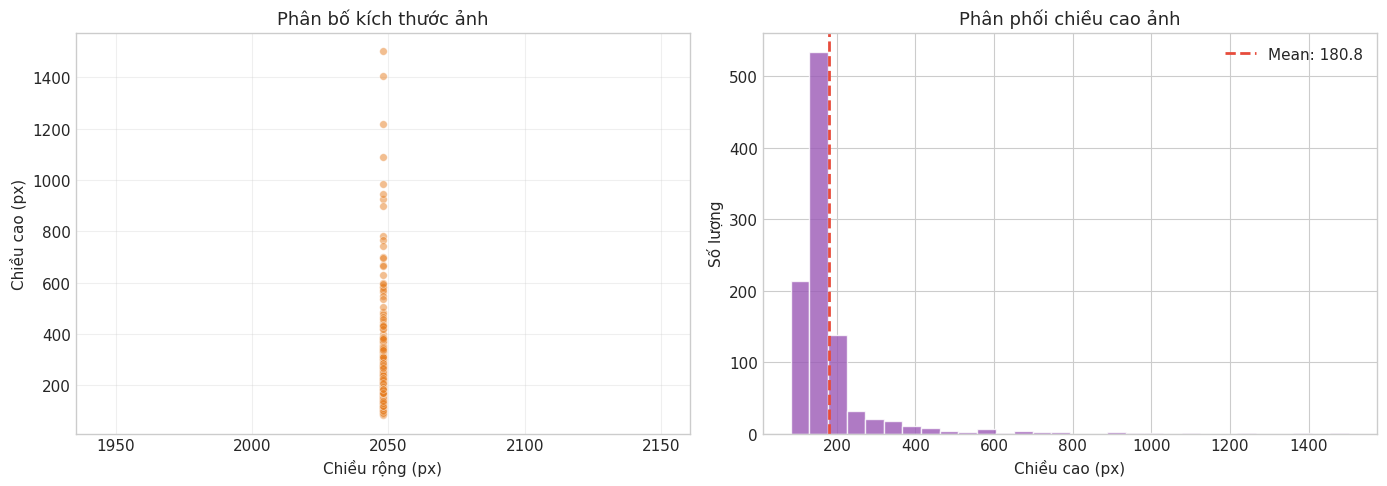

In [24]:
# Biểu đồ kích thước ảnh
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot width vs height
scatter = axes[0].scatter(valid_df['width'], valid_df['height'], 
                          alpha=0.5, c='#E67E22', s=30, edgecolors='white', linewidth=0.5)
axes[0].set_xlabel('Chiều rộng (px)')
axes[0].set_ylabel('Chiều cao (px)')
axes[0].set_title('Phân bố kích thước ảnh')
axes[0].grid(True, alpha=0.3)

# Histogram chiều cao
axes[1].hist(valid_df['height'], bins=30, color='#9B59B6', edgecolor='white', alpha=0.8)
axes[1].axvline(valid_df['height'].mean(), color='#E74C3C', linestyle='--', linewidth=2, label=f'Mean: {valid_df["height"].mean():.1f}')
axes[1].set_xlabel('Chiều cao (px)')
axes[1].set_ylabel('Số lượng')
axes[1].set_title('Phân phối chiều cao ảnh')
axes[1].legend()

plt.tight_layout()
plt.show()


## 6. Kiểm tra tính toàn vẹn dữ liệu


In [25]:
def verify_dataset_integrity(dataframe):
    """Kiểm tra tính toàn vẹn của dataset"""
    issues = {
        'empty_labels': 0,
        'missing_images': 0,
        'corrupted_images': 0
    }
    
    for _, row in dataframe.iterrows():
        # Kiểm tra nhãn trống
        if not row['text'] or row['text'].strip() == '':
            issues['empty_labels'] += 1
        
        # Kiểm tra ảnh
        if not os.path.exists(row['image']):
            issues['missing_images'] += 1
        else:
            try:
                with Image.open(row['image']) as img:
                    img.verify()
            except:
                issues['corrupted_images'] += 1
    
    return issues

# Kiểm tra trên tập nhỏ
print("🔎 Đang kiểm tra tính toàn vẹn dữ liệu (100 mẫu đầu)...")
check_df = df_train.head(100)
issues = verify_dataset_integrity(check_df)

print(f"\n📋 Kết quả kiểm tra:")
print(f"   - Nhãn trống: {issues['empty_labels']}")
print(f"   - Ảnh không tồn tại: {issues['missing_images']}")
print(f"   - Ảnh bị hỏng: {issues['corrupted_images']}")

if all(v == 0 for v in issues.values()):
    print("\n✅ Dữ liệu sạch, không phát hiện vấn đề!")
else:
    print("\n⚠️ Cần xử lý các vấn đề trên trước khi training!")


🔎 Đang kiểm tra tính toàn vẹn dữ liệu (100 mẫu đầu)...

📋 Kết quả kiểm tra:
   - Nhãn trống: 0
   - Ảnh không tồn tại: 0
   - Ảnh bị hỏng: 0

✅ Dữ liệu sạch, không phát hiện vấn đề!


In [26]:
# Lưu thống kê
summary_stats = {
    'train_samples': len(df_train),
    'test_samples': len(df_test),
    'unique_chars': len(unique_chars),
    'avg_text_length': df_train['text_length'].mean(),
    'avg_img_width': valid_df['width'].mean(),
    'avg_img_height': valid_df['height'].mean()
}

print("📊 Thống kê tổng hợp:")
for key, value in summary_stats.items():
    print(f"   - {key}: {value:.2f}" if isinstance(value, float) else f"   - {key}: {value}")


📊 Thống kê tổng hợp:
   - train_samples: 7028
   - test_samples: 201
   - unique_chars: 161
   - avg_text_length: 67.81
   - avg_img_width: 2048.00
   - avg_img_height: 180.84
